В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

/var/folders/4d/0c50ls19619c4tqyrbm08n3h0000gn/T/ipykernel_43764/1263026880.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs.drop(columns = columns_to_drop, inplace = True)
/var/folders/4d/0c50ls19619c4tqyrbm08n3h0000gn/T/ipykernel_43764/1263026880.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_inputs.drop(columns = columns_to_drop, inplace = True)


Area under ROC score on Train dataset: 0.88%


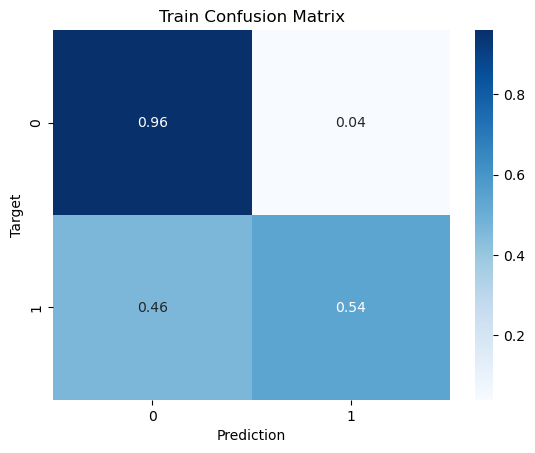

Area under ROC score on Validation dataset: 0.88%


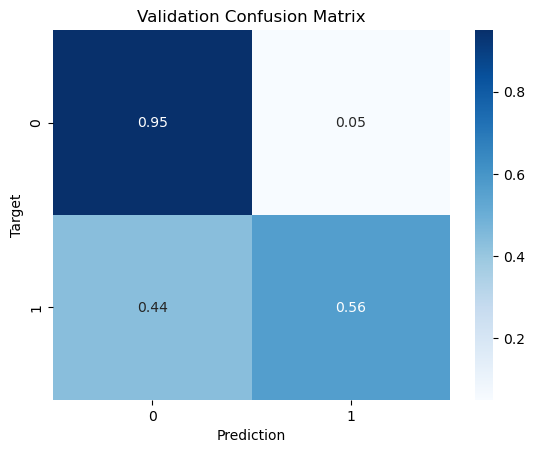

['customer_churns.joblib']

In [61]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix
import joblib

raw_df = pd.read_csv("bank-customer-churn-prediction-dlu-course-c-3/train.csv")

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify = raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

columns_to_drop = ['CustomerId', 'Surname']
train_inputs.drop(columns = columns_to_drop, inplace = True)
val_inputs.drop(columns = columns_to_drop, inplace = True)

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'customer_churns.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

/var/folders/4d/0c50ls19619c4tqyrbm08n3h0000gn/T/ipykernel_43764/3337567038.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs.drop(columns = columns_to_drop, inplace = True)
/var/folders/4d/0c50ls19619c4tqyrbm08n3h0000gn/T/ipykernel_43764/3337567038.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_inputs.drop(columns = columns_to_drop, inplace = True)


Area under ROC score on Train dataset: 0.92%


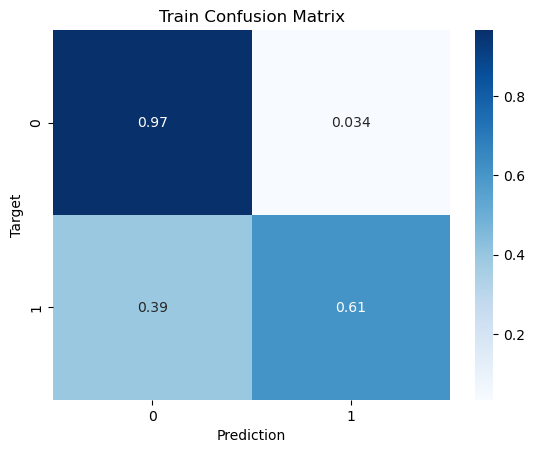

Area under ROC score on Validation dataset: 0.92%


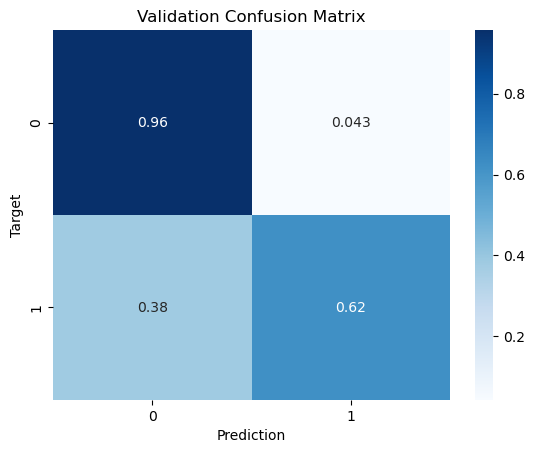

['customer_churns_p.joblib']

In [62]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix
import joblib
import operator
from sklearn.preprocessing import PolynomialFeatures


raw_df = pd.read_csv("bank-customer-churn-prediction-dlu-course-c-3/train.csv")

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify = raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

columns_to_drop = ['CustomerId', 'Surname']
train_inputs.drop(columns = columns_to_drop, inplace = True)
val_inputs.drop(columns = columns_to_drop, inplace = True)

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

# =============
numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2))
])
# =============

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# ============= 
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
# =============


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])


# ============= Пайплайн з поліноміальними фічами
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])
# =============

# Тренуємо пайплайн
model_pipeline_poly.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline_poly.predict(inputs)
    pred_proba = model_pipeline_poly.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly, 'customer_churns_p.joblib')

Вау! Після додавання фіч другого порядку модель помітно покращилася як на тренувальних даних, так і на валідаційних.  
Не спостерігається ні пере-, ні недонавчання, модель гарно генералізує. 

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

/var/folders/4d/0c50ls19619c4tqyrbm08n3h0000gn/T/ipykernel_43764/1784088451.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs.drop(columns = columns_to_drop, inplace = True)
/var/folders/4d/0c50ls19619c4tqyrbm08n3h0000gn/T/ipykernel_43764/1784088451.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_inputs.drop(columns = columns_to_drop, inplace = True)


Area under ROC score on Train dataset: 0.93%


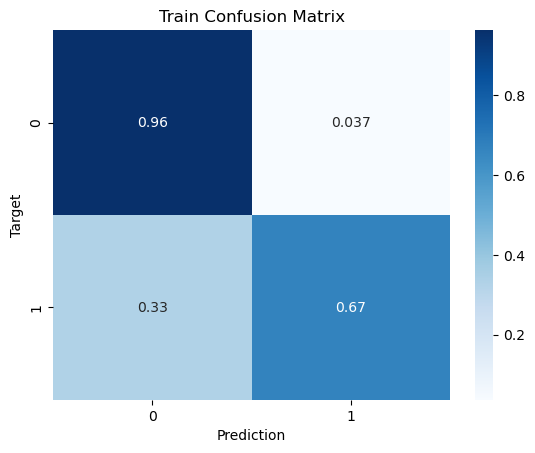

Area under ROC score on Validation dataset: 0.93%


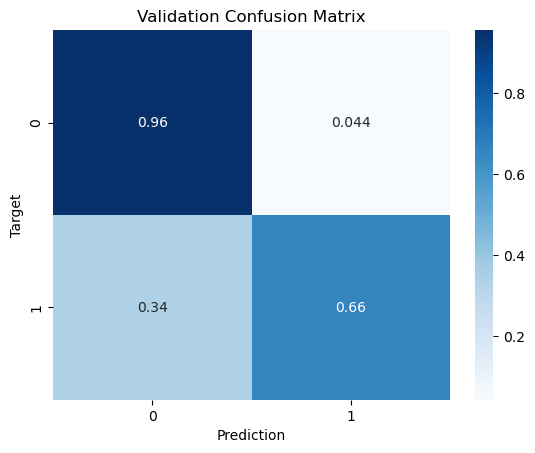

['customer_churns_p4.joblib']

In [63]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix
import joblib
import operator
from sklearn.preprocessing import PolynomialFeatures


raw_df = pd.read_csv("bank-customer-churn-prediction-dlu-course-c-3/train.csv")

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify = raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

columns_to_drop = ['CustomerId', 'Surname']
train_inputs.drop(columns = columns_to_drop, inplace = True)
val_inputs.drop(columns = columns_to_drop, inplace = True)

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

# =============
numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4))
])
# =============

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# ============= 
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
# =============


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])


# ============= Пайплайн з поліноміальними фічами
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])
# =============

# Тренуємо пайплайн
model_pipeline_poly.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline_poly.predict(inputs)
    pred_proba = model_pipeline_poly.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly, 'customer_churns_p4.joblib')

При поліноміальній регресії степеню 4 можемо побачити ще невеличке покращення результатів. Знову спостерігаємо гарну генералізацію.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [64]:
df = pd.read_csv('regression_data.csv')
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [65]:
X = df.drop(['target'],axis=1)
y = df[['target']]

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
feature_names = X_train.columns
feature_names

Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'], dtype='object')

In [68]:
scaler = MinMaxScaler().fit(X_train)

In [69]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

def train_lin_vs_poly_reg_and_plot(X_train, X_test, y_train, y_test, degree):
  # Звичайна лінійна регресія
  lin_reg = LinearRegression()
  lin_reg.fit(X_train, y_train)
  y_pred_train_lin = lin_reg.predict(X_train)
  y_pred_test_lin = lin_reg.predict(X_test)

  # Поліноміальна регресія
  poly_features = PolynomialFeatures(degree=degree)
  X_train_poly = poly_features.fit_transform(X_train)
  X_test_poly = poly_features.transform(X_test)

  print(f'В оригіналній матриці Х {X.shape[1]} ознак.')
  print(f'В матриці Х з поліноміальними ознаками {X_train_poly.shape[1]} ознак.\n')

  poly_reg = LinearRegression()
  poly_reg.fit(X_train_poly, y_train)
  y_pred_train_poly = poly_reg.predict(X_train_poly)
  y_pred_test_poly = poly_reg.predict(X_test_poly)

  # Оцінка моделей

  rmse_lin_train = root_mean_squared_error(y_train, y_pred_train_lin)
  rmse_poly_train = root_mean_squared_error(y_train, y_pred_train_poly)

  rmse_lin_test = root_mean_squared_error(y_test, y_pred_test_lin)
  rmse_poly_test = root_mean_squared_error(y_test, y_pred_test_poly)


  print(f"Train RMSE for Linear Regression: {np.sqrt(rmse_lin_train):.3f}")
  print(f"Test RMSE for Linear Regression: {np.sqrt(rmse_lin_test):.3f}\n")

  print(f"Train RMSE for Polynomial Regression (degree {degree}): {np.sqrt(rmse_poly_train):.3f}")
  print(f"Test RMSE for Polynomial Regression (degree {degree}): {np.sqrt(rmse_poly_test):.3f}")

In [71]:
degree = 5
train_lin_vs_poly_reg_and_plot(X_train, X_test, y_train, y_test, degree)

В оригіналній матриці Х 5 ознак.
В матриці Х з поліноміальними ознаками 252 ознак.

Train RMSE for Linear Regression: 1.033
Test RMSE for Linear Regression: 0.940

Train RMSE for Polynomial Regression (degree 5): 0.000
Test RMSE for Polynomial Regression (degree 5): 4.012


Модель лінійної регресії доволі добре генералізує — значення rmse на тренувальному та тестовому наборах даних є близькими. В цілому, це хороша модель регресії для наших даних.
Однак модель поліноміальної регресії 5 степеню оверфітнулась: точно підігналася по всім точкам наших тренувальних даних (rmse = 0), але показала себе погано на тестових даних

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [72]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet()
]

In [73]:
poly_features = PolynomialFeatures(degree=20)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [74]:
X_train_poly.shape

(103, 53130)

In [75]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_metrics = root_mean_squared_error(y_train, y_train_pred).round(6)
    test_metrics = root_mean_squared_error(y_test, y_test_pred).round(6)

    return dict(train=train_metrics, test=test_metrics)

In [76]:
for model in models:
    model.fit(X_train_poly, y_train)
    eval_results  = evaluate_model(model, X_train_poly, y_train, X_test_poly, y_test)
    print(f'{str(model)}: {eval_results}\n')

LinearRegression(): {'train': 0.0, 'test': 12.992893}

Ridge(): {'train': 5.885065, 'test': 7.02105}

Lasso(): {'train': 5.098171, 'test': 5.671931}

ElasticNet(): {'train': 30.034532, 'test': 30.442414}



Переможець очевидний 😅 Lasso модель найкраще генералізує з усіх трьох, певно через те, що вона автоматично зануляє коефіцієнти непотрібних фіч, яких у нас аж 53130 🫣 на таку малу кількість даних   
ElasticNet дала занадто велику похибку, можливо варто спробувати підкрутити alpha  
А лінійна регресія взагалі дуже сильно перенавчилася 

In [77]:
model = Lasso()
model.fit(X_train_poly, y_train)

X_train = pd.DataFrame(X_train, columns=feature_names)


coefs_df = pd.DataFrame(poly_features.get_feature_names_out(X_train.columns), columns=['feature_name'])
coefs_df['value'] = model.coef_.round(5).flatten()

In [78]:
coefs_df.set_index('feature_name').sort_values(by='value', ascending=False).head(30).style.background_gradient()

,value
feature_name,
feature_4,194.929250
1,0.000000
feature_1^7 feature_3^3 feature_4^8 feature_5,0.000000
feature_1^7 feature_3^4 feature_4^8,0.000000
feature_1^7 feature_3^4 feature_4^7 feature_5,0.000000
feature_1^7 feature_3^4 feature_4^6 feature_5^2,0.000000
feature_1^7 feature_3^4 feature_4^5 feature_5^3,0.000000
feature_1^7 feature_3^4 feature_4^4 feature_5^4,0.000000
feature_1^7 feature_3^4 feature_4^3 feature_5^5,0.000000


Ну, власне 🙈 Фактично єдиною важливою ознакою є лише feature_4, інші були розцінені моделлю як нерелевантні